  <div class="alert alert-info">
  Привет, Александр! Меня зовут Светлана Чих и я буду проверять твой проект. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе. Предлагаю общаться на «ты». Но если это не удобно - дай знать, и мы перейдем на «вы».

  <div class="alert alert-success">
  <b>👍 Успех:</b> Зелёным цветом отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Рекомендация:</b> Жёлтым цветом выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).
  </div>
  <div class="alert alert-danger">
  <b>😔 Необходимо исправить:</b> Красным цветом выделены комментарии, без исправления которых, я не смогу принять проект :(
  </div>
  <div class="alert alert-info">
  <b>👂 Совет:</b> Какие-то дополнительные материалы
  </div>
  Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом.
  Мне будет легче отследить изменения, если ты выделишь свои комментарии:
  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
  Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии. Всё это поможет выполнить повторную проверку твоего проекта быстрее.
   </div>

# Исследовательский анализ данных бронирования билетов на сервисе Яндекс Афиша

Автор: Александр 

Дата : 06.03.2026

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных для выявления причин роста количества заказов, но снижения стоимости, влияния сезонности, пользовательских предпочтений осенью 2024 года, а также проверить гипотезы о разном количестве заказов с ипользование мобильного или стационарного устройства

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить распределение заказов по сегментам и их сезонное распределение;
    - изучить осеннюю активност;
    - изучить популярные события и партнеров.
4. Провести статистический анализ данных.
5. Сформулировать выводы по проведённому анализу и дать рекомендации


## Данные

Для анализа поступили данные о бронировании билетов . Данные состоят из трех датасетов:

- `final_tickets_orders_df.csv` — информация обо всех заказах билетов с мобильных и стационарных устройств;
- `final_tickets_events_df.csv` —   информация о событиях, площадках и мероприятиях.
- `final_tickets_tenge_df.csv` —   информация о курсе тенге к Российскому рублю. (значения для 100 тенге)

### Описание датасета `final_tickets_orders_df`

- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circui` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, mobile/desktop .
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя

### Описание датасета `final_tickets_events_df`

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

### Описание датасета `final_tickets_tenge_df`

- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Итоговые выводы.

<div class="alert alert-success">
<b>👍 Успех:</b> Отличная описательная часть, есть цели и задачи проекта! Молодец!
</div>

## Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `final_tickets_orders_df` и `final_tickets_events_df`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik -q
from phik import phik_matrix

sns.set() #сделаем стиль графиков seaborn основным.
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.0f}'.format

<div class="alert alert-success">
<b>👍 Успех:</b> Молодец, что загружаешь все библиотеки в начале проекта. Так сложней случайно удалить ячейку с загрузкой нужной библиотеки и сделать код не работающим. А получатель отчета сразу поймет, какие библиотеки ты используешь и какие ему нужно установить для запуска проекта.
</div>

In [2]:
# Функции используемые в проекте
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

In [3]:
# загружаем датафреймы
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [4]:
# Выводим первые строки датафрейма на экран
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289,Мой билет,2,2068,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1259,За билетом!,4,13984,75
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8,Лови билет!,2,212,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390,Билеты без проблем,3,10695,83


In [5]:
# Выводим информацию о датафрейме
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет `final_tickets_orders_df.csv` содержит 14 столбцов и 290849 строк, в которых представлена информация о заказах

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов отображены корректно.
- Необходимо изменить тип данных в следующих столбцах:
    - `created_dt_msk` - привести к datetime
    - `created_ts_msk` - привести к datetime
    - `days_since_prev` - привести к int
- Пропуски в данных отсутствуют за исключением поля `days_since_prev`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `final_tickets_events_df.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
# Выводим первые строки датафрейма на экран
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет `final_tickets_events_df.csv` содержит 11 столбцов и 22427 строк, в которых представлена информация о событиях, городах, регионах и площадках

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов отображены корректно.
- Типы данных соответствуют
- Пропуски в данных отсутствуют.
- Значения в столбцах соответствуют своему описанию.

<div class="alert alert-success">
<b>👍 Успех:</b> Данные загружены и просмотрены. 
    
При считывании данных из файла здорово перестраховывать себя от ошибок, связанных, например, с неверным указанием пути к файлу. А иногда бывает, что работаешь с файлом локально, выгружаешь его на сервер, ожидая, что он будет принимать данные, которые лежат на том же сервере, а код падает с ошибкой, потому что путь к файлу не поменялся с локального на серверный.
Для этого, например, можно использовать конструкцию `try-except`: сначала пробуешь локальный путь, при возникновении ошибки используется серверный путь (подробнее можешь почитать тут: https://pythonworld.ru/tipy-dannyx-v-python/isklyucheniya-v-python-konstrukciya-try-except-dlya-obrabotki-isklyuchenij.html).
Но еще лучше использовать библиотеку `os` - её использование позволит тебе проверять существование указанных директорий (что может быть актуально при одновременной работа на локальном и сетевом окружении) и загружать данные из существующей директории, избегая ошибок. Как пример:

    import os

    pth1 = '/folder_1/data.csv'
    pth2 = '/folder_2/data.csv'

    if os.path.exists(pth1):
        query_1 = pd.read_csv(pth1)
    elif os.path.exists(pth2):
        query_1 = pd.read_csv(pth2)
    else:
        print('Something is wrong')

Ещё на этапе считывания данных можно спарсить дату: за это действие отвечает параметр `parse_dates` метода `read_csv()`, в него нужно передать список с названием полей-дат, и в большинстве случаев дата будет корректно преобразована в нужный формат сразу:)
Также на этапе считывания данных задать индекс-столбец- за это действие отвечает параметр `index_col`.
</div>

## Предобработка данных





###  Подготовка единого датафрейма

In [8]:
###  Подготовка единого датафрейма
df=orders_df.merge(events_df, on='event_id',how='inner')
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141,Край билетов,3,8153,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Почему здесь выбран именно левый тип объединения? Нам нужны данные, где не совпал event_id?</s>
</div>

  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Поправил</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Проверяем наличие пропусков в данных



In [9]:
# изучим пропуски с помощью функции 
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21913,0.0754


<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Да, изначально нужен был inner, объединять 2 раза не нужно, нужно исправить выше
</div>

In [10]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
tmp = df.copy() 
len(tmp)


290611

### Анализ значений в ключевых столбцах

In [11]:
# Проверяем категориальные значения
# Проверяем уникальность значений и их количество в столбцах
for column in ['device_type_canonical','currency_code','event_type_main']:
    display(f'Уникальные значения в столбце {column} :')
    display(df[column].sort_values().unique().tolist())  
    count_unique=df[column].nunique()
    display(f'количество уникальных значений в столбце {column} = {count_unique}')   

'Уникальные значения в столбце device_type_canonical :'

['desktop', 'mobile']

'количество уникальных значений в столбце device_type_canonical = 2'

'Уникальные значения в столбце currency_code :'

['kzt', 'rub']

'количество уникальных значений в столбце currency_code = 2'

'Уникальные значения в столбце event_type_main :'

['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

'количество уникальных значений в столбце event_type_main = 7'

в результате анализа выявлен не совсем понятный тип мероприятия "другое" в поле `event_type_main`. Посмотрим на описание типов возможно получится идентифицировать по косвенным признакам

In [12]:
#display(df.query("event_type_main == 'другое'")['event_type_description'].value_counts())
#pivot_type=df.pivot_table()
group_types = df.groupby(['event_type_main', 'event_type_description'])['event_type_description'].agg('count').sort_values(ascending=False).unstack(fill_value=0)
group_types

event_type_description,балет,выставка,концерт,кукольный спектакль,музыкальный спектакль,мюзикл,опера,оперетта,подарок,рок-мюзикл,снегурочка,событие,спектакль,спорт,спортивное мероприятие,фестиваль,цирковое шоу,шоу,экскурсия,ёлка
event_type_main,,,,,,,,,,,,,,,,,,,,
выставки,0,0,0,0,0,0,0,0,0,0,0,4746,1,0,0,93,0,14,0,0
другое,0,5876,0,13,140,0,0,7,4,1,3,53716,0,0,0,0,5213,886,8,0
концерты,0,0,111098,0,0,0,0,0,0,0,0,0,0,0,0,4178,0,0,0,0
спорт,0,0,0,0,0,0,0,0,0,0,0,0,0,12837,9074,0,0,0,0,0
стендап,0,0,857,0,0,0,0,0,0,0,0,143,37,0,0,2,0,12354,0,0
театр,5848,0,0,0,0,9672,1297,0,0,0,0,0,50504,0,0,0,0,0,0,0
ёлки,150,0,94,0,0,247,17,0,0,0,0,0,50,0,0,0,114,372,0,945


принимаем решение сделать соответствие для части событий с типом "другое" :
- выставка                  5876 - выставки
- кукольный спектакль         13 - театр
- музыкальный спектакль      140 - театр
- оперетта                     7 - театр
- рок-мюзикл                   1 - театр
- подарок                      4 - ёлка (подразумеваем новогодний)
- снегурочка                   3 - ёлка
- цирковое шоу              5213 - цирк (создадим новый тип в `event_type_main`)
- шоу                        886 - оставляем другое (невозможно определить выставка, стендап или елка )
- экскурсия                    8 - оставляем другое 

In [13]:
# заменим значения ориентируясь на соответствие выше
df.loc[df['event_type_description'] == 'выставка' , 'event_type_main'] = 'выставки'
df.loc[df['event_type_description'] == 'кукольный спектакль' , 'event_type_main'] = 'театр'
df.loc[df['event_type_description'] == 'оперетта' , 'event_type_main'] = 'театр'
df.loc[df['event_type_description'] == 'музыкальный спектакль' , 'event_type_main'] = 'театр'
df.loc[df['event_type_description'] == 'рок-мюзикл' , 'event_type_main'] = 'театр'
df.loc[df['event_type_description'] == 'подарок' , 'event_type_main'] = 'ёлки'
df.loc[df['event_type_description'] == 'снегурочка' , 'event_type_main'] = 'ёлки'
df.loc[df['event_type_description'] == 'цирковое шоу' , 'event_type_main'] = 'цирк'

In [14]:
print(df['event_type_main'].value_counts())

концерты    115276
театр        67482
другое       54610
спорт        21911
стендап      13393
выставки     10730
цирк          5327
ёлки          1882
Name: event_type_main, dtype: int64


In [15]:
df['revenue'].describe()

count   290611
mean       626
std       1228
min        -91
25%        117
50%        356
75%        810
max      81175
Name: revenue, dtype: float64

На этом нормализацию данных завершим, да остался достаточно есмкий тип "другое", но конкретизировать его на 100% не получается, по категориям валюта и тип устройств - все ок.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

In [16]:
# Далее анализируем количественные значения

In [17]:
# разделим массив на 2 группы по валютам rub и kzt
df_rub=df[df['currency_code']=='rub']
df_kzt=df[df['currency_code']=='kzt']

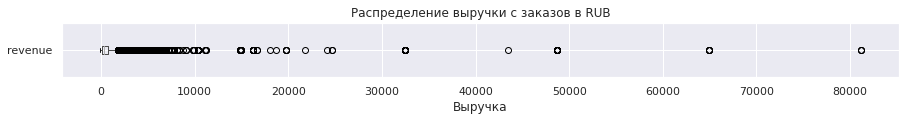

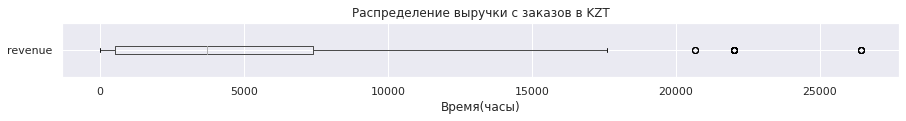

In [18]:
# построим диаграму размаха для значений revenue каждой группы
plt.figure(figsize=(15, 1))
df_rub.boxplot(column='revenue',vert=False)
plt.title('Распределение выручки с заказов в RUB')
plt.xlabel('Выручка')
plt.show()                 
                 
plt.figure(figsize=(15, 1))
df_kzt.boxplot(column='revenue',vert=False)
plt.title('Распределение выручки с заказов в KZT')
plt.xlabel('Время(часы)')
plt.show() 

Text(0, 0.5, 'Частота')

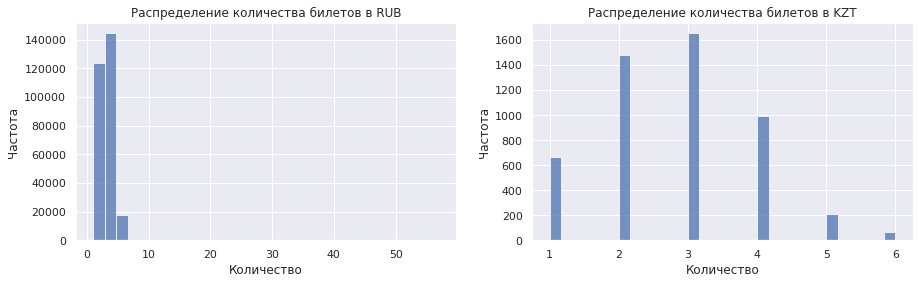

In [19]:
# Построим гистограмму для каждой группы
fig, axes = plt.subplots(1, 2, figsize=(15, 4))  # Создаем фигуру с двумя осями

# Строим гистограмму для группы rub на первой оси
df_rub['tickets_count'].plot(kind='hist', bins=30, alpha=0.75, ax=axes[0])
axes[0].set_title('Распределение количества билетов в RUB')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Частота')

# Строим гистограмму для группы kzt на второй оси
df_kzt['tickets_count'].plot(kind='hist', bins=30, alpha=0.75, ax=axes[1])
axes[1].set_title('Распределение количества билетов в KZT')
axes[1].set_xlabel('Количество')
axes[1].set_ylabel('Частота')

По билетам в рублях видны выбросы, далее проанализирую и решу

In [20]:
#проанализируем поле revenue df_rub
df_rub['revenue'].describe()


count   285542
mean       548
std        872
min        -91
25%        114
50%        347
75%        793
max      81175
Name: revenue, dtype: float64

В поле revenue видим наличие выбросов и отрицательные значения.

In [21]:
# оставим значения, которые будут положительные и  войдут в 99%
df = df[df['revenue'] >= 0]
df = df[df['revenue'] < df['revenue'].quantile(0.99)]
df_rub=df[df['currency_code']=='rub']
df_rub['revenue'].describe()

count   284594
mean       531
std        545
min          0
25%        115
50%        346
75%        789
max       4003
Name: revenue, dtype: float64

теперь лучше

In [22]:
df_kzt['revenue'].describe()

count    5069
mean     4995
std      4917
min         0
25%       518
50%      3699
75%      7398
max     26426
Name: revenue, dtype: float64

Стандартое отклонение и среднее близки по значениям, разброз данных  минимальный, что подтверждает диаграмма размаха. Данные корректны.

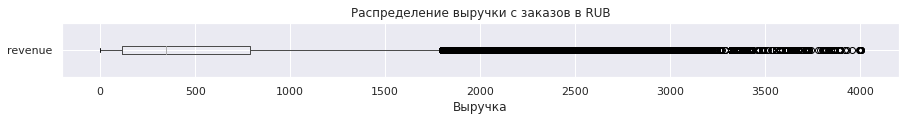

In [23]:
#посмотрим еще раз на распределение выручки
plt.figure(figsize=(15, 1))
df_rub.boxplot(column='revenue',vert=False)
plt.title('Распределение выручки с заказов в RUB')
plt.xlabel('Выручка')
plt.show() 

<div class="alert alert-success">
<b>👍 Успех:</b> Отлично, с выбросами разобрались!
</div>

### Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [24]:
# Посмотрим на дубликаты 
df.duplicated().sum()

0

явных дубликатов нет. проверяем наличие дубликатов без учета номера заказа

In [25]:
# Получаем список всех столбцов, кроме 'created_ts_msk'
columns_to_check = df.columns.drop('order_id')

# Проверяем дубликаты по выбранным столбцам
duplicates = df[columns_to_check].duplicated()

# Подсчитываем количество дубликатов
num_duplicates = duplicates.sum()
num_duplicates

30

найдено 30 дубликатов, которые необходимо удалить

In [26]:
#оставляем первую встречающуюся строку для каждого набора дубликатов.
df = df.drop_duplicates(subset=columns_to_check, keep='first')

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Оптимизируем типы данных

In [27]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
df['days_since_prev'].fillna(0, inplace=True)
df['days_since_prev'] = df['days_since_prev'].astype('int32')
print(df.dtypes)


order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                     object
device_type_canonical             object
revenue                          float64
service_name                      object
tickets_count                      int64
total                            float64
days_since_prev                    int32
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int64
venue_id                           int64
venue_name                        object
venue_address                     object
dtype: object


### Создание новых столбцов



In [28]:
# выделяем месяц из даты, проверяем
df['month'] = df['created_dt_msk'].dt.month
df['month'].unique()

array([ 8,  7, 10,  9,  6])

In [29]:
# с помощью функции создаем категории сезонности, проверяем
def season_category(month):
    if month in [12,1,2]:
        return 'зима'
    elif month in [3,4,5]:
        return 'весна'
    elif month in [6,7,8]:
        return 'лето'
    elif month in [9,10,11]:
        return 'осень'

df['season'] = df['month'].apply(season_category)
df['season'].unique()

array(['лето', 'осень'], dtype=object)

In [30]:
#tenge_df.dtypes
#приведем поле date к типу datetime для успешного объединения таблиц
tenge_df['data']=pd.to_datetime(tenge_df['data'])
# добавляем данные с курсом
tenge_df = tenge_df.rename(columns={'data': 'created_dt_msk'})
df = df.merge(tenge_df, on='created_dt_msk', how='left')


In [31]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,month,season,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",8,лето,100,19,kzt
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141,Край билетов,3,8153,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt


In [32]:
# с помощью функции переведем выручку в рубли
def kzt_to_rub(revenue, currency_code, curs):
    if currency_code == 'kzt':
        return revenue / 100 * curs
    else:
        return revenue

df['revenue_rub'] = df.apply(lambda x: kzt_to_rub(x['revenue'],x['currency_code'], x['curs']), axis=1)
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,month,season,nominal,curs,cdx,revenue_rub
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",8,лето,100,19,kzt,1522
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt,1902
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141,Край билетов,3,8153,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt,1141
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902,Край билетов,5,13589,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt,1902
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1522,Край билетов,4,10871,0,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",7,лето,100,18,kzt,1522


In [33]:
# рассчитываем выручку с продажи одного билета на мероприятие.
df['one_ticket_revenue_rub']=df['revenue_rub']/df['tickets_count']
df['one_ticket_revenue_rub'].head()

0   380
1   380
2   380
3   380
4   380
Name: one_ticket_revenue_rub, dtype: float64

In [34]:
# Проверим сколько удалено строк датасета
tmp2 = df.copy() 
a, b = len(tmp), len(tmp2)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 290611 
 Осталось строк в датасете после обработки 287296 
 Удалено строк в датасете после обработки 3315 
 Процент потерь 1.14


###  Промежуточные выводы после предобработки

В результате предобработки данных были выполнены следующие действия:

- Загрузка данных:
    - Датасет `final_tickets_orders_df.csv`:
    Содержит 14 столбцов и 290 849 строк.Включает информацию о заказах, такую как даты создания заказов (`created_dt_msk`, `created_ts_msk`), количество дней с предыдущего события (`days_since_prev`), и другие данные связанные с заказами.
    - Датасет `final_tickets_events_df.csv`:
    Состоит из 11 столбцов и 22 427 строк.
    Представляет информацию о событиях, включая данные о городах, регионах, площадках и типах мероприятий.
    
    
 - Объединение данных:
     - Объеденили два основных датафрейма `final_tickets_orders_df` и `final_tickets_events_d`f. При слиянии образовались пропуски в количестве 238 штук, которые были удалены при альтернативном присоединении типа "inner"
     - Присоединили данные о курсе валюты, приведя поле date к типу datetime для успешного слияния таблиц.
     

- Нормализация значений
    - Провели нормализацию части данных типов мероприятий  «другое» на соответствующее из   описания
    - По диаграмме размаха определили выбросы и оставили 99% данных в поле revenue
    - Удалили отрицательные значения в поле revenue


- Анализ дубликатов:
    - Явных дубликатов выявлено небыло.
    - Было выявлено 30 неявных дубликатов без учета id номера заказа, которые были удалены

    
    
- Оптимизация типов данных:
    - Привели столбцы `created_dt_msk` и `created_ts_msk` к типу datetime.
    - Изменили тип данных в столбце `days_since_prev` на int32 


- Создание новых столбцов:
    - Выделили месяц из даты в столбце `created_dt_msk` и создали новый столбец `month`.
    - На основе месяца создали категорию сезонности в столбце `season`.
    - Привели к рублевому эквиваленту данные по выручке в KZT. Отобразили всю рублевую выручку в столбце `revenue_rub`.
    
    
- Расчёт новых метрик:
    - Рассчитали выручку с продажи одного билета на мероприятие в поле `one_ticket_revenue_rub`


В процессе предобработки данных было удалено 3553 строк (290849 было/287296 осталось). Потери составили 1.22 %

<div class="alert alert-success">
<b>👍 Успех:</b> Отлично! Данные обработаны и готовы для дальнейшего анализа!
</div>

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменеия

In [35]:
# Проверяем пользовательскую активность в связи с сезонностью
#days_first = days_first_sessions.groupby('session_date').agg({'session_id': 'count', 'good_session':'sum'}).reset_index()

In [36]:
event_dinamic = df.groupby(['event_type_main', 'month'])['user_id'].count().unstack(fill_value=0)
event_dinamic

month,6,7,8,9,10
event_type_main,,,,,
выставки,1139,1870,1822,2171,3628
другое,7522,9767,9939,12277,14780
концерты,13900,16860,18623,25155,38176
спорт,263,714,2030,7970,10893
стендап,1527,2157,2697,3058,3886
театр,7423,8302,8458,17762,25322
цирк,718,962,997,862,1786
ёлки,59,61,123,337,1300


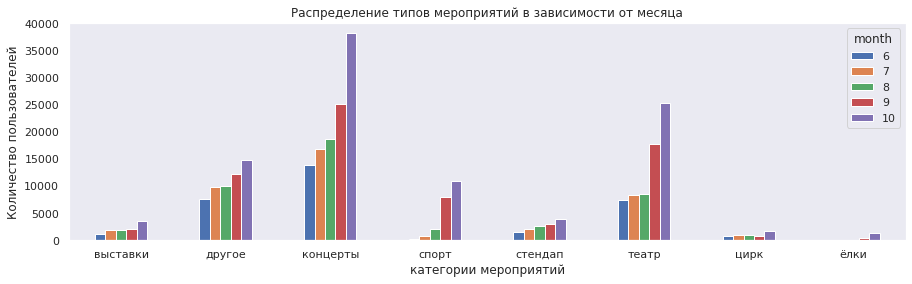

In [37]:
# Построим график распределения категорий в зависимости от месяцев.
# Пользовательской активность будем считать количество пользователей
event_dinamic.plot(kind='bar',
               title=f'Распределение типов мероприятий в зависимости от месяца',
               legend=True,
               ylabel='Количество пользователей',
               xlabel='категории мероприятий',
               rot=0,
               figsize=(15, 4))
plt.grid()

# Выводим график
plt.show()

По всем категориям видно увеличение числа пользователей в осенние месяцы, а в октябре еще больше чем в сентябре

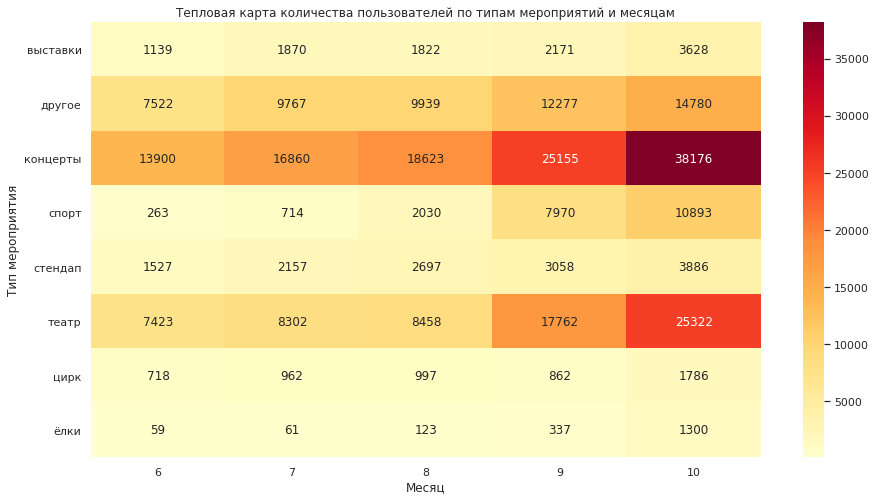

In [38]:
# Рассмотрим другой тип визуализации heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(event_dinamic, annot=True, fmt="d", cmap='YlOrRd')
plt.title('Тепловая карта количества пользователей по типам мероприятий и месяцам')
plt.xlabel('Месяц')
plt.ylabel('Тип мероприятия')
plt.show()

Данная визуализация дает четкое понимание увеличения числа пользователей в осенние месяцы, с выделением явных лидеров по категориям

In [39]:
device_dinamic = df.groupby(['month','device_type_canonical'])['user_id'].count().unstack(fill_value=0)
device_dinamic

device_type_canonical,desktop,mobile
month,,
6,6246,26305
7,8036,32657
8,8319,36370
9,13453,56139
10,21087,78684


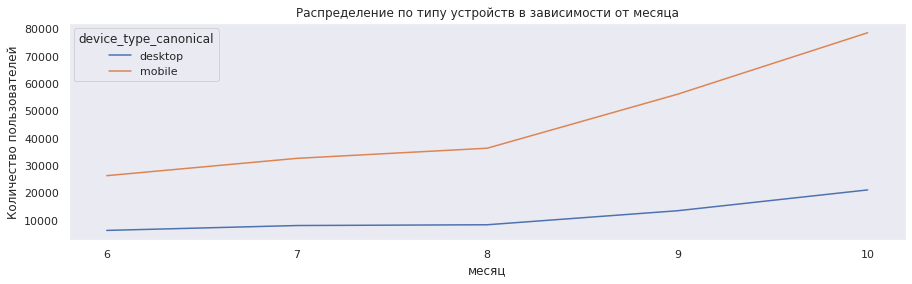

In [40]:
# Построим график распределения по типу устройств в зависимости от месяцев.
# Пользовательской активность будем считать количество пользователей
device_dinamic.plot(kind='line',
               title=f'Распределение по типу устройств в зависимости от месяца',
               legend=True,
               ylabel='Количество пользователей',
               xlabel='месяц',
               rot=0,
               figsize=(15, 4))
plt.grid()
plt.xticks(device_dinamic.index) 
# Выводим график
plt.show()

Также как и с категориями, наблюдается ежемесячное увеличение, преобладание пользователей использующих мобильные устройства сохраняется на протяжении всего периода. Резкий рост с сентября

In [41]:
age_dinamic = df.groupby(['month', 'age_limit'])['user_id'].count().unstack(fill_value=0)
age_dinamic

age_limit,0,6,12,16,18
month,,,,,
6,5582,6079,6834,9419,4637
7,6685,7918,7690,11772,6628
8,9211,7940,8833,12023,6682
9,15875,12956,15895,17670,7196
10,23870,17178,21480,26715,10528


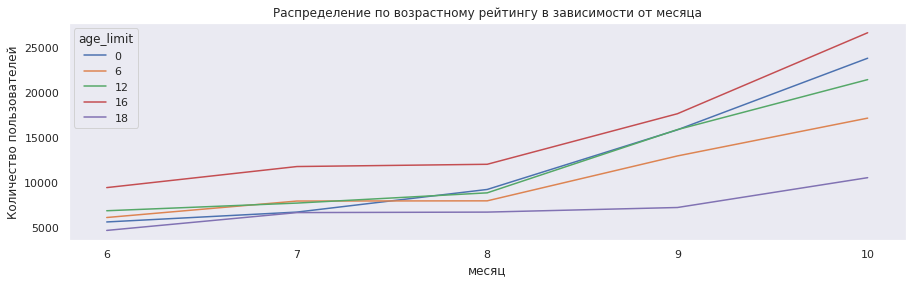

In [42]:
# Построим график распределения возрастного рейтинга в зависимости от месяцев.
# Пользовательской активность будем считать количество пользователей
age_dinamic.plot(kind='line',
               title=f'Распределение по возрастному рейтингу в зависимости от месяца',
               legend=True,
               ylabel='Количество пользователей',
               xlabel='месяц',
               rot=0,
               figsize=(15, 4))
plt.grid()
plt.xticks(device_dinamic.index) 
# Выводим график
plt.show()

рост доли пользователей заметен для всех возрастных категорий в осенний период, единственное отличие по категории "18" рост начинается в октябре, в то время как по остальным категориям рост наблюдается с первого месяца осени.

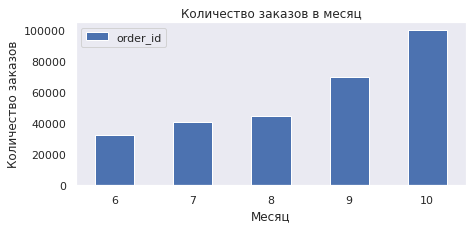

In [43]:
# Количество заказов в месяц
orders_month=df.groupby('month')['order_id'].nunique()
orders_month.plot(kind='bar',
               title=f'Количество заказов в месяц',
               legend=True,
               ylabel='Количество заказов',
               xlabel='Месяц',
               rot=0,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

За период июнь-октябрь количество заказов растет ежемесячно, резкий рост наблюдается в сентябре и октябре.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Наблюдается рост заказов. Молодец, что так подробно посмотрел в разрезе категорий
</div>

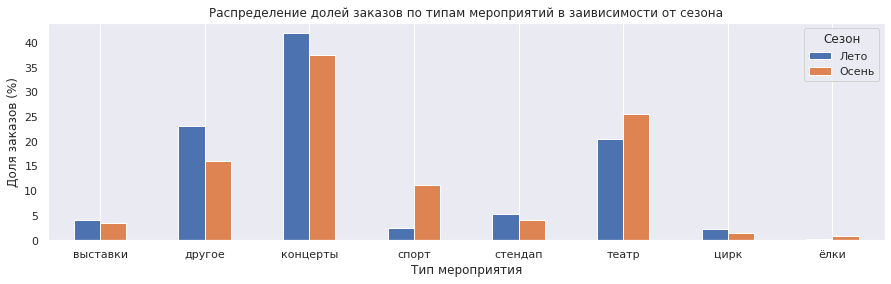

In [44]:
# Сравнение распределений заказов билетов летом и осенью по категориям
# Фильтруем массив по нужным сезонам
summer = df[df['season'] == 'лето']
autumn = df[df['season'] == 'осень']

# Группировка данных по категориям и расчёт долей для летнего сезона и осеннего сезонов
summer_event = summer['event_type_main'].value_counts(normalize=True) * 100
autumn_event = autumn['event_type_main'].value_counts(normalize=True) * 100

# Объединяем данные 
data_event = pd.DataFrame({'Лето': summer_event, 'Осень': autumn_event})

#Строим диаграммы
data_event.plot(kind='bar', title='Распределение долей заказов по типам мероприятий в заивисимости от сезона',
          ylabel='Доля заказов (%)', xlabel='Тип мероприятия', rot=0,
          figsize=(15, 4))
plt.grid(axis='y')
plt.legend(title='Сезон')

Видим увеличение доли заказов осенью в следующих категориях: театр, спорт, елки, по остальным идет снижение

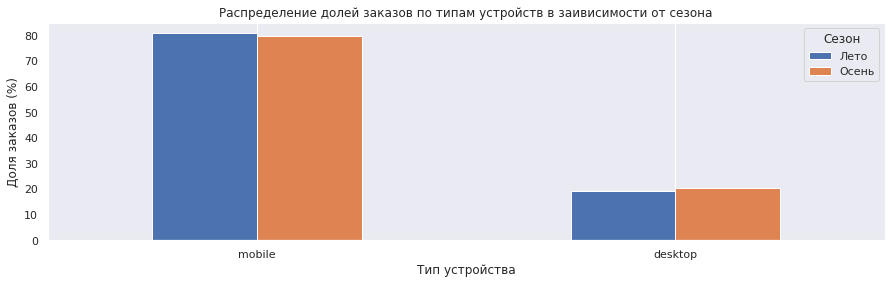

In [45]:
# Группировка данных по типам устройств и расчёт долей для летнего сезона и осеннего сезонов
summer_device = summer['device_type_canonical'].value_counts(normalize=True) * 100
autumn_device = autumn['device_type_canonical'].value_counts(normalize=True) * 100

# Объединяем данные 
data_device = pd.DataFrame({'Лето': summer_device, 'Осень': autumn_device})

#Строим диаграммы
data_device.plot(kind='bar', title='Распределение долей заказов по типам устройств в заивисимости от сезона',
          ylabel='Доля заказов (%)', xlabel='Тип устройства', rot=0,
          figsize=(15, 4))
plt.grid(axis='y')
plt.legend(title='Сезон')

В сентябре доля заказов незначительно перераспределяется с мобильников на ПК. В целом преобладание заказов через мобильные телефоны сохраняется

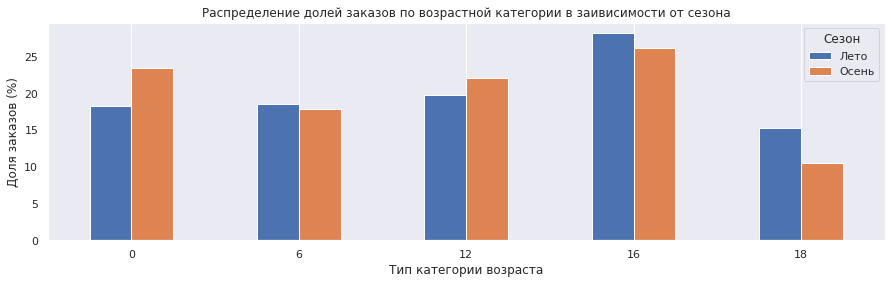

In [46]:
# Группировка данных по типам устройств и расчёт долей для летнего сезона и осеннего сезонов
summer_age = summer['age_limit'].value_counts(normalize=True) * 100
autumn_age = autumn['age_limit'].value_counts(normalize=True) * 100

# Объединяем данные 
data_age = pd.DataFrame({'Лето': summer_age, 'Осень': autumn_age})

#Строим диаграммы

data_age.plot(kind='bar', title='Распределение долей заказов по возрастной категории в заивисимости от сезона',
          ylabel='Доля заказов (%)', xlabel='Тип категории возраста', rot=0,
          figsize=(15, 4))
plt.grid(axis='y')
plt.legend(title='Сезон')

Явного перераспределения не наблюдается, небольшое увеличение в категории "0" и небольшое снижение в категории "18"

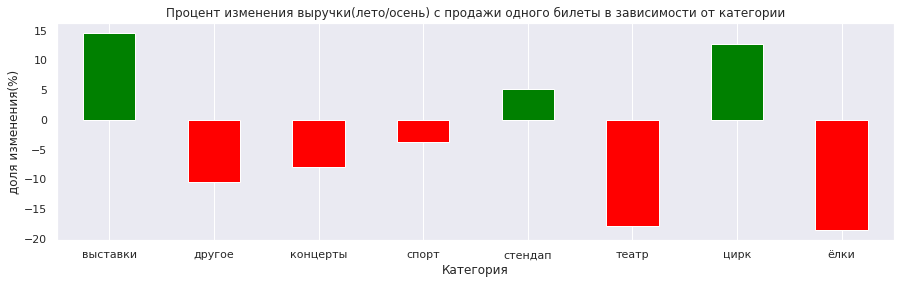

In [47]:
# Изменение выручки с продажи одного билеты

# Группировка данных по категориям и расчёт средней выручки с одного билета для летнего сезона и осеннего сезонов
summer_one_ticket_rev = summer.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_one_ticket_rev = autumn.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Объединяем данные 
data_one_ticket_rev = pd.DataFrame({'Лето': summer_one_ticket_rev, 'Осень': autumn_one_ticket_rev})
data_one_ticket_rev_per=(data_one_ticket_rev['Осень']-data_one_ticket_rev['Лето'])/data_one_ticket_rev['Лето']*100

#Строим диаграммы
colors = np.where(data_one_ticket_rev_per > 0, 'green', 'red')
data_one_ticket_rev_per.plot(kind='bar',color=colors, title='Процент изменения выручки(лето/осень) с продажи одного билеты в зависимости от категории',
          ylabel='доля изменения(%)', xlabel='Категория', rot=0,
          figsize=(15, 4))
plt.grid(axis='y')
plt.show()


Рост выручки на 15% приходится на категорию выставки и незначительный рост по категориям стендап(до 5%) и цирк(до 12%). Однако по остальным категориям выручка снизилась, особенно в категории театр и елки на 17-18%

Вывод :


 - С наступлением осени наблюдается увеличение числа пользователей и количества заказов во всех категориях. Особенно заметен рост в категориях «театр», «спорт» и «ёлки».
 

 - Преобладание пользователей, использующих мобильные устройства, сохраняется, хотя в сентябре доля заказов незначительно перераспределяется с мобильников на ПК.
 
 
 - Средняя стоимость одного билета меняется в зависимости от категории мероприятия:
       * значительный рост выручки на 13-15% в категориях «выставки» и «цирк» ;
       * незначительный рост 5% для категории «стендап»;
       * снижение выручки по остальным категориям, особенно в категории «театр» и «елки» на 17-18%.
Это говорит о том, что изменение средней стоимости билета зависит от типа мероприятия и может быть как положительным, так и отрицательным.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Осенняя активность пользователей

In [48]:
# Динамика изменений осенних показателей по дням 
# Создадим сводную таблицу по дням 
pivot_autumn = pd.pivot_table(autumn, values=['order_id', 'user_id'], index=['created_dt_msk'], aggfunc=['nunique']).reset_index()
pivot_autumn.columns = pivot_autumn.columns.droplevel(0)
pivot_autumn = pivot_autumn.rename(columns={'': 'created_dt_msk'})
pivot_autumn = pivot_autumn.set_index('created_dt_msk')
pivot_autumn['avg_orders_one_users']=pivot_autumn['order_id']/pivot_autumn['user_id']
print(pivot_autumn.sort_values('order_id', ascending=False).head())

                order_id  user_id  avg_orders_one_users
created_dt_msk                                         
2024-10-01          7307     1103                     7
2024-10-31          5978     1276                     5
2024-09-03          5094      777                     7
2024-10-25          4569     1224                     4
2024-10-15          3911     1101                     4


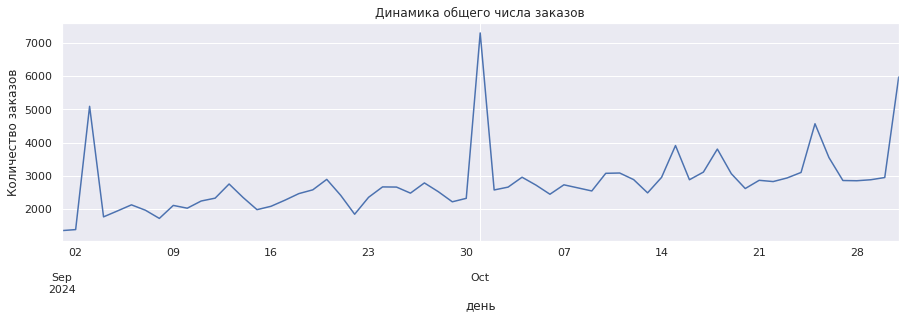

In [49]:
# Динамика общего числа заказов
pivot_autumn['order_id'].plot(kind='line', figsize=(15, 4))
plt.title('Динамика общего числа заказов')
plt.xlabel('день')
plt.ylabel('Количество заказов')
plt.show()

Динамика количества заказов положительная, ярко выражены скачки в следующие дни:
 - 2024-09-03	- 5094
 - 2024-10-01	- 7307
 - 2024-10-31   - 5978

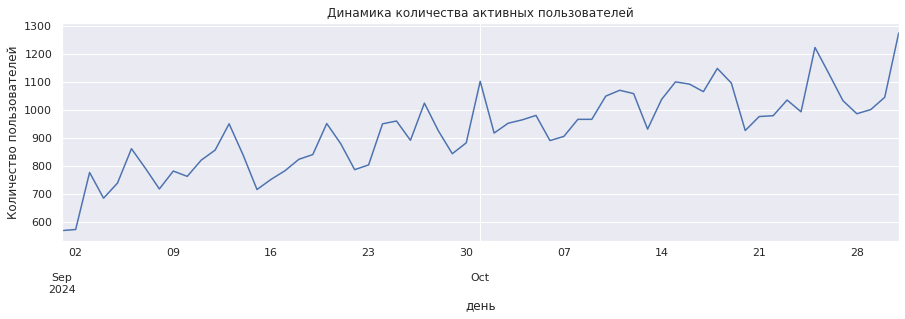

In [50]:
# Динамика количества активных пользователей
pivot_autumn['user_id'].plot(kind='line', figsize=(15, 4))
plt.title('Динамика количества активных пользователей')
plt.xlabel('день')
plt.ylabel('Количество пользователей')
plt.show()

График волатилен, но в целом динамика роста числа пользователей положительная

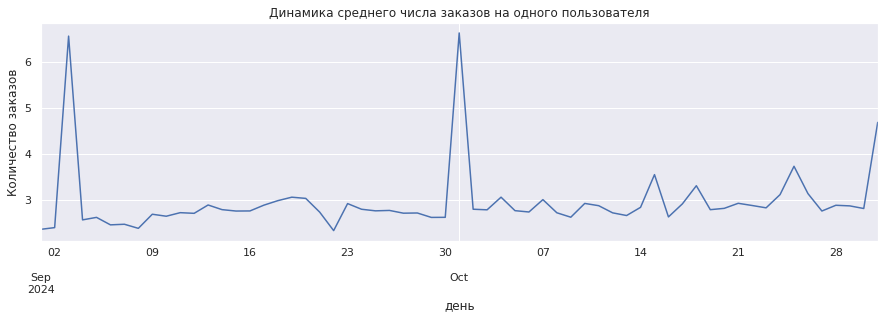

In [51]:
# Динамика среднего числа заказов на одного пользователя
pivot_autumn['avg_orders_one_users'].plot(kind='line', figsize=(15, 4))
plt.title('Динамика среднего числа заказов на одного пользователя')
plt.xlabel('день')
plt.ylabel('Количество заказов')
plt.show()

График схож с Динамикой общего числа заказов. 

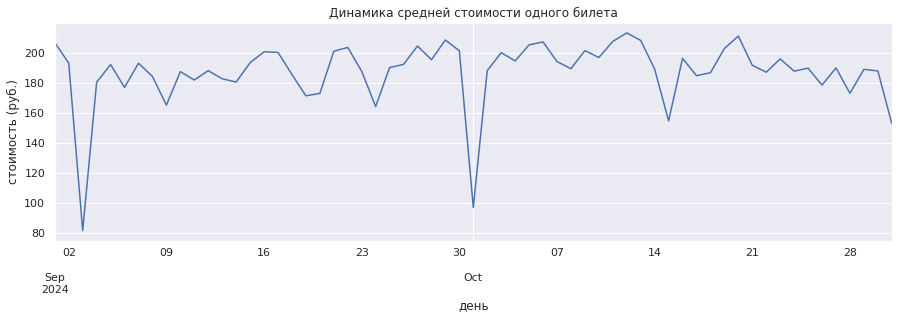

In [52]:
# Выводим ежедневную динамику средней стоимости одного билета
avg_cost_ticket = autumn.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean()
avg_cost_ticket.plot(kind='line', figsize=(15, 4))
plt.title('Динамика средней стоимости одного билета')
plt.xlabel('день')
plt.ylabel('стоимость (руб.)')
plt.show()

Видно снижение стоимости в те же даты когда происходили массовые заказы. Есть предположение о скидках(акциях) в размере 50% 3-го сентября и 1 октября и скидке в размере 25% 31 октября.

In [53]:
# недельная ацикличность
autumn['day_of_week'] = autumn['created_dt_msk'].dt.day_name()

/tmp/ipykernel_217/1158086658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autumn['day_of_week'] = autumn['created_dt_msk'].dt.day_name()


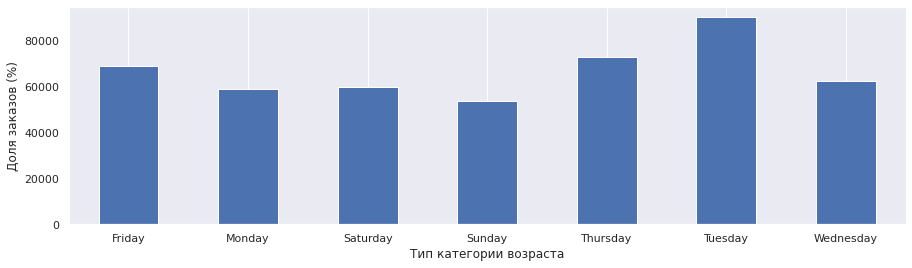

In [54]:
# проверим пользовательскую активность по дням недели используя количество билетов
autumn_weekend = autumn.groupby('day_of_week')['tickets_count'].sum()


#Строим диаграмму

autumn_weekend.plot(kind='bar', title='',
          ylabel='Доля заказов (%)', xlabel='Тип категории возраста', rot=0,
          figsize=(15, 4))
plt.grid(axis='y')


Пользовательская активность имеет положительную динамику, имеются скачки увеличения числа заказов, что влияет на стоимость одного билета.


Есть 2 предположения, либо это акции о снижении стоимости, что провоцирует увеличение покупок, либо это какаято ошибка в количестве заказов.


Касательно недельной цикличности, можно сделать вывод о том, что самым популярным днем оказался вторник. Самым не популярным воскресенье.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Увеличивается количество активных пользователей и конверсия в заказы!
</div>

### Популярные события и партнеры

In [55]:
# Распределение событий по регионам
group_region = df.groupby(by='region_name').agg(count_event=('event_id', 'nunique'),count_orders=('order_id', 'count')).sort_values(by='count_event', ascending=False).head(10).reset_index()
group_region

,region_name,count_event,count_orders
0,Каменевский регион,5966,90669
1,Североярская область,3807,43952
2,Широковская область,1226,16376
3,Светополянский округ,1068,7560
4,Речиновская область,701,6289
5,Травяная область,683,5042
6,Горицветская область,551,5162
7,Серебринская область,541,5608
8,Яблоневская область,534,6170
9,Тепляковская область,529,4387


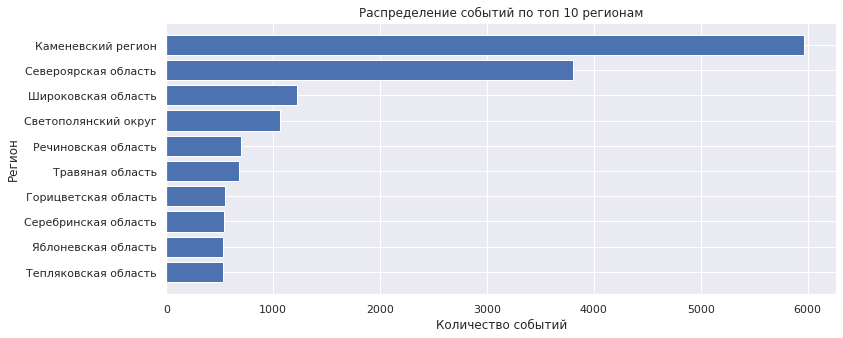

In [56]:
# Строим график распределения событий   
plt.figure(figsize=(12, 5))
plt.barh(group_region['region_name'], group_region['count_event'])
plt.xlabel('Количество событий')
plt.ylabel('Регион')
plt.title('Распределение событий по топ 10 регионам')
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы максимальные значения были вверху

In [57]:
# считаем долю мероприятий в каждом регионе
group_region_per = df['region_name'].value_counts(normalize=True) * 100
group_region_per.head(30)

Каменевский регион          32
Североярская область        15
Широковская область          6
Медовская область            5
Озернинский край             4
Светополянский округ         3
Малиновоярский округ         2
Речиновская область          2
Солнечноземская область      2
Яблоневская область          2
Серебринская область         2
Горицветская область         2
Травяная область             2
Лугоградская область         2
Тепляковская область         2
Солнечнореченская область    1
Зоринский регион             1
Глиногорская область         1
Чистогорская область         1
Лесодальний край             1
Заречная область             1
Травиницкий округ            1
Ветренский регион            1
Боровлянский край            1
Каменноозёрный край          1
Шанырский регион             1
Речицкий регион              1
Каменноярский край           1
Малиновая область            1
Верхоречная область          0
Name: region_name, dtype: float64

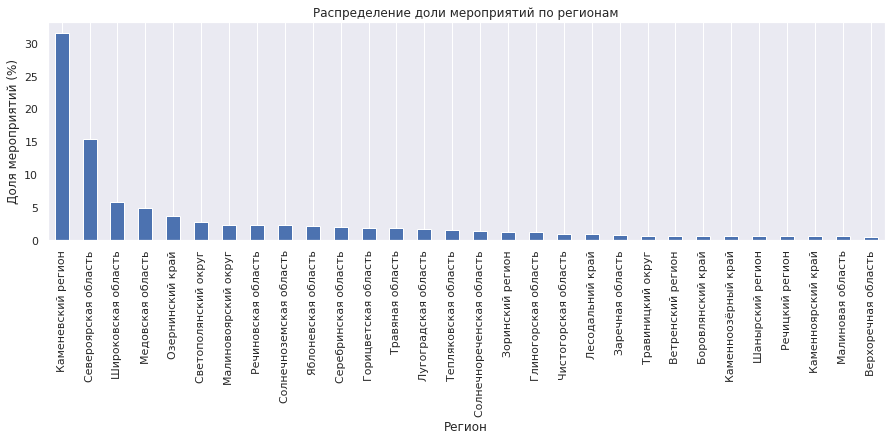

In [58]:
#Строим диаграмму

group_region_per.head(30).plot(kind='bar', title='',
          ylabel='Доля мероприятий (%)', xlabel='Регион', rot=90,
          figsize=(15, 4))
plt.title('Распределение доли мероприятий по регионам')
plt.grid(axis='y')

Распределение событий по регионам:

Среди топовых регионов (по разнообразию мероприятий) выделяется:

 * Каменевский регион 5966 мероприятий - 32%
 * Североярская область 3807 - 15%	
 * Широковская область	1226 - 6%

In [59]:
# Распределение мероприятий по регионам
group_service = df.groupby(by='service_name').agg(
                                            count_event=('event_id', 'nunique'),
                                            count_orders=('order_id', 'count'),
                                            sum_revenue=('revenue_rub', 'sum')).sort_values(by='count_event', ascending=False).head(10).reset_index()
group_service

,service_name,count_event,count_orders,sum_revenue
0,Лови билет!,4870,41068,17573417
1,Билеты без проблем,4216,62880,25519091
2,Билеты в руки,3523,40237,13341638
3,Облачко,2343,26557,19041297
4,Лучшие билеты,1755,17743,2810530
5,Мой билет,1305,32753,19264518
6,Тебе билет!,1061,5224,3065270
7,Прачечная,1027,10273,4900985
8,Весь в билетах,864,16731,17445459
9,Яблоко,715,5038,3966819


Распределение Лидеры среди партнеров:

Среди топовых регионов (по разнообразию мероприятий) выделяется:

service_name	count_event	count_orders	sum_revenue
 * Лови билет!	4870	41068	17573417 руб.
 *	Билеты без проблем	4216	62880	25519091 руб.
 *	Билеты в руки	3523	40237	13341638 руб.

Распределение событий по регионам: 
- Каменевский регион является явным лидером с 5966 мероприятиями, что составляет 32% от общего числа. Это указывает на высокую активность и разнообразие культурной жизни в этом регионе. 
- Североярская область занимает второе место с 3807 мероприятиями (15%), что также свидетельствует о значительном вкладе в общее число событий. 
- Широковская область с 1226 мероприятиями (6%) демонстрирует меньшее, но всё же существенное участие.

По следующим 27 регионам мероприятия распределены равномерно по 1-2 %, по следующим 50 менее 1го процента.

Эти данные показывают, что распределение мероприятий неравномерно, с явным преобладанием Каменевского региона.


Лидеры среди партнёров: 
- «Лови билет!» лидирует по количеству мероприятий (4870), количеству заказов (41068) и суммарной выручке (17 573 417 руб.).
- «Билеты без проблем» занимает второе место по количеству мероприятий (4216) и первое место по выручке (25 519 091 руб.), что указывает на эффективность их работы и популярность у клиентов. 
- «Билеты в руки» с 3523 мероприятиями и 40 237 заказами показывает хорошие результаты, но отстаёт по выручке по сравнению с другими лидерами.


Таким образом, среди партнёров также наблюдается неравномерное распределение активности и выручки, с «Лови билет!» и «Билеты без проблем» в качестве явных лидеров.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Среди регионов явно выделяются 2 лидера, а среди партнеров одно агентство лидирует с большим отрывом!
</div>

## Статистический анализ данных

Среднее количество заказов на одного пользователя


Первая гипотеза: 

- Нулевая гипотеза (H0): среднее количество заказов на одного пользователя мобильного приложения не отличается от среднего количества заказов на одного пользователя стационарных устройств.


- Альтернативная гипотеза (H1): среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств.

применение t-теста Уэлча

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Здесь тоже стоит взять тест Уэлча, и проверить все расчеты, что у тебя в n_a, n_b, m_a и m_b?</s>
</div>

In [60]:
# общее количество заказов для двух групп
total_orders = autumn.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()

# отбираем группы
mobile = total_orders[total_orders['device_type_canonical']=='mobile']['order_id']
pc = total_orders[total_orders['device_type_canonical']=='desktop']['order_id']

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    mobile, 
    pc, 
    equal_var=False,
    alternative='greater' # так как H_1: p_a > p_b
) 

# применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={p_value_welch_ttest}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
else:
    print(f'p-value теста Уэлча ={p_value_welch_ttest}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны')

p-value теста Уэлча =0.0008412604646433553
Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны


Описание теста:

- Нулевая гипотеза (H0): среднее количество заказов на одного пользователя мобильного приложения не отличается от среднего количества заказов на одного пользователя стационарных устройств.

- Альтернативная гипотеза (H1): среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств. 

- Тест проводился с использованием уровня значимости alpha = 0.05 и параметром equal_var=False, что означает предположение о неравных дисперсиях выборок.

Результаты теста: 

- Полученное значение p-value = 0.00084, что меньше уровня значимости 0.05. - Это означает, что нулевая гипотеза не находит подтверждения, и можно сделать вывод о том, что среднее количество заказов на пользователя мобильного приложения действительно выше, чем у пользователей стационарных устройств.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

Вторая гипотиза

Среднее время между заказами

 - Нулевая гипотеза (H0): среднее время между заказами пользователей мобильных приложений не отличается от среднего времени между заказами пользователей стационарных устройств.
 
 
 - Альтернативная гипотеза (H1): среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств.
 
 
применение t-теста Уэлча

In [61]:
# общее выборка заказов с расчетом среднего времени между заказов
avg_time_between_orders = autumn.groupby(['order_id','device_type_canonical'])['days_since_prev'].mean().reset_index()

# отбираем группы
metric_a_mobile = avg_time_between_orders[avg_time_between_orders.device_type_canonical=='mobile']['days_since_prev'] # Выборка целевой метрики для группы A
metric_b_pc = avg_time_between_orders[avg_time_between_orders.device_type_canonical=='desktop']['days_since_prev'] # Выборка целевой метрики для группы B


alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a_mobile, 
    metric_b_pc, 
    equal_var=False,
    alternative='greater' # так как H_1: p_a > p_b
) 

# применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={p_value_welch_ttest}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
else:
    print(f'p-value теста Уэлча ={p_value_welch_ttest}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны')
   

p-value теста Уэлча =6.2653680767544835e-21
Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны


In [62]:
# проверка средних значений
mb = avg_time_between_orders[avg_time_between_orders.device_type_canonical=='mobile']['days_since_prev'].mean()
pc = avg_time_between_orders[avg_time_between_orders.device_type_canonical=='desktop']['days_since_prev'].mean()
print (f'значения мобильных:{round(mb,2)}')
print (f'значения мобильных:{round(pc,2)}')

значения мобильных:3.58
значения мобильных:2.9


Описание теста: 

- Нулевая гипотеза (H0): среднее время между заказами пользователей мобильных приложений не отличается от среднего времени между заказами пользователей стационарных устройств. 

- Альтернативная гипотеза (H1): среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств. 
- Тест проводился с использованием уровня значимости alpha = 0.05 и параметром equal_var=False, что означает предположение о неравных дисперсиях выборок.

Результаты теста: 

- Полученное значение p-value = 6.2653680767544835e-21, что значительно меньше уровня значимости 0.05.

- Это означает, что нулевая гипотеза не находит подтверждения, и можно сделать вывод о том, что среднее время между заказами у пользователей мобильных приложений действительно выше, чем у пользователей стационарных устройств.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> p-value не может быть равен 0, округлять его нельзя, и еще раз проверь как сформулирована альтернативная гипотеза и что в выводе (исправить нужно вывод)</s>
</div>

Общий вывод


Информация о данных: - Были обработаны два основных датасета: final_tickets_orders_df (290 849 строк) и final_tickets_events_df (22 427 строк). - Данные содержат информацию о заказах, событиях, регионах, площадках и типах мероприятий.
Основные результаты анализа:
- Популярность мероприятий: с наступлением осени наблюдается увеличение числа пользователей и количества заказов во всех категориях. Особенно заметен рост в категориях «театр», «спорт» и «ёлки». 
- Средняя стоимость билета: изменение средней стоимости билета зависит от типа мероприятия. Заметный рост выручки в категориях «выставки» и «цирк», незначительный рост в категории «стендап», снижение выручки в категориях «театр» и «ёлки».
- Региональное распределение: Каменевский регион является явным лидером по количеству мероприятий (32% от общего числа). Североярская область занимает второе место (15%). 
- Лидеры среди партнёров: «Лови билет!» лидирует по количеству мероприятий, заказов и суммарной выручке. «Билеты без проблем» занимает второе место по количеству мероприятий и первое место по выручке.


Результаты проверки гипотез:

- Среднее количество заказов на одного пользователя:

Среднее количество заказов на пользователя мобильного приложения статистически значимо выше, чем у пользователей стационарных устройств. Это указывает на то, что пользователи мобильных приложений совершают больше заказов в среднем по сравнению с пользователями стационарных устройств.

- Среднее время между заказами:

Среднее время между заказами у пользователей мобильных приложений также статистически значимо выше, чем у пользователей стационарных устройств. Это может означать, что пользователи мобильных приложений делают заказы с более длительными перерывами по сравнению с пользователями стационарных устройств.

Рекомендации
1. Анализ акций и специальных предложений: учитывая скачки увеличения числа заказов, стоит проанализировать влияние акций на стоимость билетов и общее количество покупок. 
2. Исследование региональных особенностей: уделить внимание анализу активности в регионах с неравномерным распределением мероприятий, чтобы выявить потенциальные возможности для расширения. 
3. Оптимизация пользовательского опыта: учитывая различия в поведении пользователей мобильных и стационарных устройств, стоит рассмотреть возможность оптимизации интерфейса и функциональности приложения для улучшения пользовательского опыта. 
4. Анализ эффективности партнёров: провести детальный анализ эффективности работы партнёров, чтобы определить стратегии для повышения выручки и количества заказов.
5. Стоит добавить регулярные уведомления для пользователей с мобильными о популярных мероприятиях , чтобы стимулировать интерес и желание делать заказ чаще.

<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Еще точно полно времени на доработку))) В целом все вполне неплохо!
</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Отличная работа, молодец! 
    
Отдельно хочу отметить итоговый вывод, у него понятная структура, его легко читать и можно быстро найти нужную информацию. Он охватывает все части работы и можно прочитав только вывод понять все важные моменты, при необходимости всегда можно обратиться к нужному разделу и посмотреть подробности. 
    
Работа аналитиком предполагает постоянное развитие, поэтому порекомендую тебе несколько интересных книг и ресурсов:
    
- Статистика и котики Владимир Савельев
- Как лгать при помощи статистики Даррел Хафф
- Ложь, наглая ложь и статистика Тим Харфорд
- Голая статистика Чарльз Уилан
- бесплатный курс по DataLens https://practicum.yandex.ru/profile/ycloud-datalens/ и еще много интересного обучения https://yandex.cloud/ru/training/training-pro#Data
- тренажер по SQL https://sql-academy.org/ru/trainer
    
</div>